Q2, a)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
np.random.seed(7969)

sample_df = df.sample(n=25)

In [3]:
sample_mean = sample_df['Glucose'].mean()
sample_max = sample_df['Glucose'].max()

In [4]:
pop_mean = df['Glucose'].mean()
pop_max = df['Glucose'].max()

In [5]:
print("Sample Mean Glucose:", sample_mean)
print("Population Mean Glucose:", pop_mean)

print("Sample Max Glucose:", sample_max)
print("Population Max Glucose:", pop_max)

Sample Mean Glucose: 124.68
Population Mean Glucose: 120.89453125
Sample Max Glucose: 197
Population Max Glucose: 199


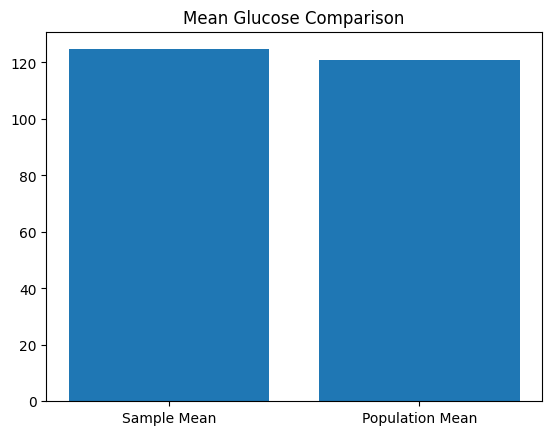

In [6]:
labels = ['Sample Mean', 'Population Mean']
values = [sample_mean, pop_mean]

plt.figure()
plt.bar(labels, values)
plt.title('Mean Glucose Comparison')
plt.show()

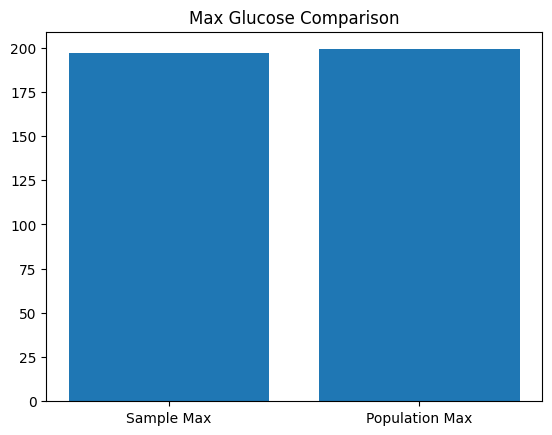

In [7]:
labels = ['Sample Max', 'Population Max']
values = [sample_max, pop_max]

plt.figure()
plt.bar(labels, values)
plt.title('Max Glucose Comparison')
plt.show()

The bar charts show that the sample mean and population mean of Glucose are very close.
This indicates that the sample is representative of the population.
Similarly, the sample maximum Glucose value is also close to the population maximum.
Overall, the sample provides a good estimate of the population statistics.

Q2, b)

In [8]:
# Sample 98th percentile
sample_bmi_98 = sample_df['BMI'].quantile(0.98)

# Population 98th percentile
pop_bmi_98 = df['BMI'].quantile(0.98)

print("Sample BMI 98th percentile:", sample_bmi_98)
print("Population BMI 98th percentile:", pop_bmi_98)

Sample BMI 98th percentile: 40.128
Population BMI 98th percentile: 47.52599999999996


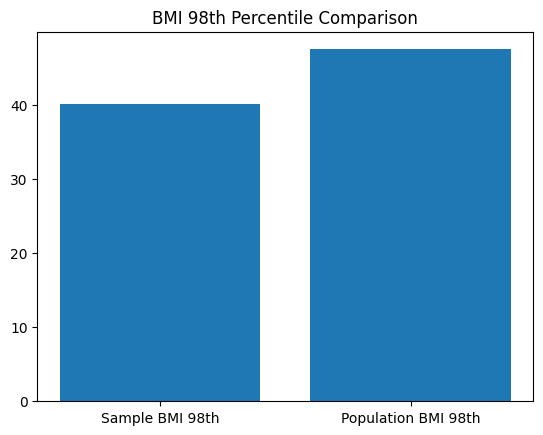

In [9]:
labels = ['Sample BMI 98th', 'Population BMI 98th']
values = [sample_bmi_98, pop_bmi_98]

plt.figure()
plt.bar(labels, values)
plt.title('BMI 98th Percentile Comparison')
plt.show()

The sample 98th percentile is lower than the population, showing that samples may miss extreme values.

Q2, c)

In [10]:
np.random.seed(7969)

means = []
stds = []
percentiles = []

# Bootstrap
for i in range(500):
    sample = df.sample(n=150, replace=True)

    means.append(sample['BloodPressure'].mean())
    stds.append(sample['BloodPressure'].std())
    percentiles.append(sample['BloodPressure'].quantile(0.98))

In [11]:
boot_mean = np.mean(means)
boot_std = np.mean(stds)
boot_percentile = np.mean(percentiles)

print("Bootstrap Mean:", boot_mean)
print("Bootstrap Std:", boot_std)
print("Bootstrap 98th Percentile:", boot_percentile)

Bootstrap Mean: 69.05554666666666
Bootstrap Std: 19.40805440187572
Bootstrap 98th Percentile: 97.90112000000002


In [12]:
pop_mean_bp = df['BloodPressure'].mean()
pop_std_bp = df['BloodPressure'].std()
pop_percentile_bp = df['BloodPressure'].quantile(0.98)

print("Population Mean:", pop_mean_bp)
print("Population Std:", pop_std_bp)
print("Population 98th Percentile:", pop_percentile_bp)

Population Mean: 69.10546875
Population Std: 19.355807170644777
Population 98th Percentile: 99.31999999999994


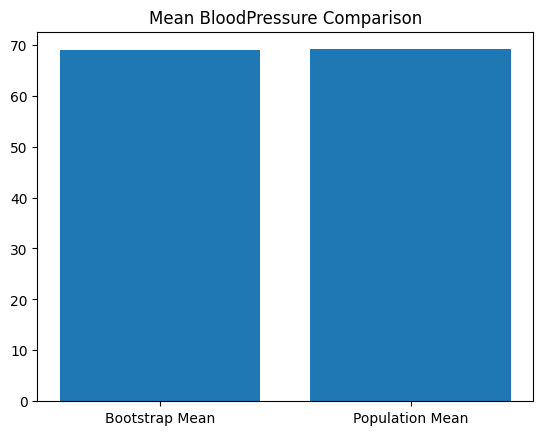

In [13]:
plt.figure()
plt.bar(['Bootstrap Mean', 'Population Mean'], [boot_mean, pop_mean_bp])
plt.title('Mean BloodPressure Comparison')
plt.show()

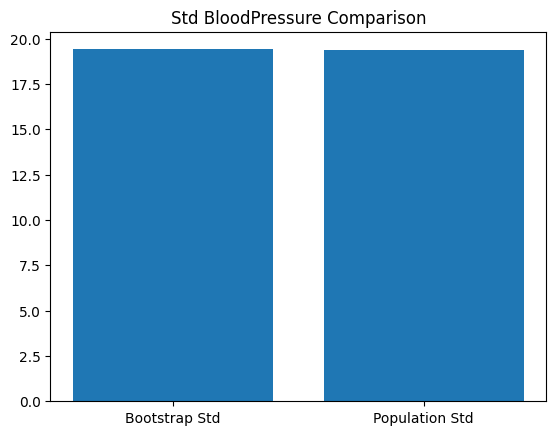

In [14]:
plt.figure()
plt.bar(['Bootstrap Std', 'Population Std'], [boot_std, pop_std_bp])
plt.title('Std BloodPressure Comparison')
plt.show()

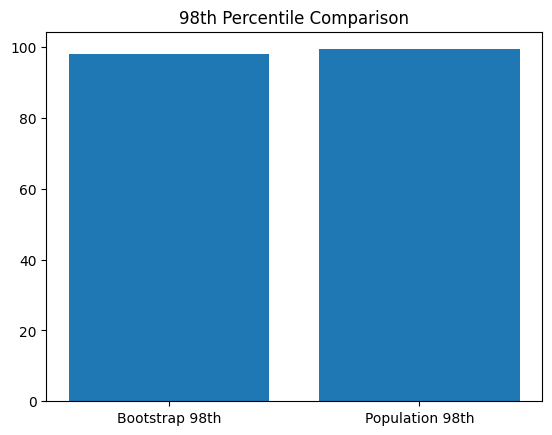

In [15]:
plt.figure()
plt.bar(['Bootstrap 98th', 'Population 98th'], [boot_percentile, pop_percentile_bp])
plt.title('98th Percentile Comparison')
plt.show()

Findings:
The bootstrap estimates of mean, standard deviation, and 98th percentile are very close to the population values.
This indicates that bootstrap sampling provides a reliable approximation of the population distribution.
Small differences are expected due to sampling variability and sensitivity of tail statistics.